<a href="https://colab.research.google.com/github/parviza9999/InterviewN/blob/main/Pytorch_intro_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PyTorch centers around torch.Tensor. Unlike standard Python lists, these are designed for massive parallelism and GPU acceleration.

**Lets initialize a standard tensor.**

We define the device, which is crucial for deep learning—you will eventually want to move your model and data to cuda for speed.

We create a dummy_image in the specific NCHW format required by PyTorch Convolutional layers.

In [ ]:
import torch

# 1. Create a tensor (like a NumPy array)
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(f"Tensor:\n{x}")

# 2. Check device (to ensure we can move to GPU later)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 3. Reshaping for CNNs
# CNNs expect 4D inputs: (Batch_Size, Channels, Height, Width)
# Let's create a single grayscale image (1 channel) of 28x28
dummy_image = torch.randn(1, 1, 28, 28)
print(f"Dummy image shape: {dummy_image.shape}")

Tensor:
tensor([[1., 2.],
        [3., 4.]])
Using device: cpu
Dummy image shape: torch.Size([1, 1, 28, 28])


The assignment device = 'cuda' is a common line of code used in machine learning frameworks like PyTorch to specify that computations should be performed on an NVIDIA GPU rather than the CPU.
When you set a device to cuda, PyTorch uses the NVIDIA CUDA Toolkit  to interface with the GPU hardware.


Next lets learn the "Sequential" way to creating a CNN architecture in Pytorch and training it.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Prepare Data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)



In [ ]:
# 2. Define Model using nn.Sequential
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Flatten(),
    nn.Linear(32 * 13 * 13, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

Why did I calculate 32 * 13 * 13?In Keras, you don't have to define the input size for Dense layers because Keras calculates it for you. In PyTorch, the nn.Linear layer needs to know exactly how many features it is receiving.

Start: $28 \times 28$

After Conv2D(kernel=3, padding=0): $(28-3+1) = 26 \rightarrow 26 \times 26$

After MaxPool(2,2): $26 / 2 = 13 \rightarrow 13 \times 13$

Final Volume: $32$ channels $\times 13 \times 13 = 5408$ neurons.



In [ ]:
# 3. Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss() # Note: CrossEntropyLoss applies Softmax internally

In [ ]:
# 4. Training Loop
model.train()
for epoch in range(2):
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 200 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx} | Loss: {loss.item():.4f}")

Epoch 1 | Batch 0 | Loss: 2.3184
Epoch 1 | Batch 200 | Loss: 0.1170
Epoch 1 | Batch 400 | Loss: 0.1615
Epoch 1 | Batch 600 | Loss: 0.1695
Epoch 1 | Batch 800 | Loss: 0.1372
Epoch 2 | Batch 0 | Loss: 0.0677
Epoch 2 | Batch 200 | Loss: 0.0908
Epoch 2 | Batch 400 | Loss: 0.0411
Epoch 2 | Batch 600 | Loss: 0.1002
Epoch 2 | Batch 800 | Loss: 0.0221


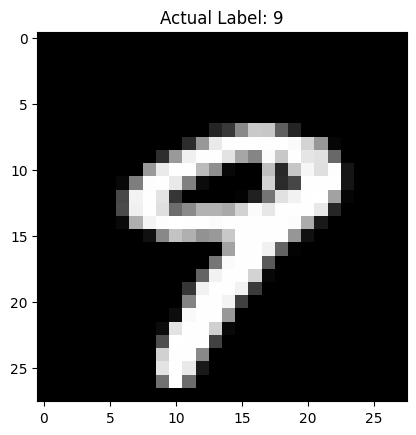

Predicted label: 9


In [ ]:
import matplotlib.pyplot as plt
import torch
testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
# 1. Get image and label from the tuple
# testset[5] returns (image_tensor, label)
image_tensor, label = testset[9]

# To plot: remove channel dimension (C, H, W) -> (H, W) and move to CPU
plt.imshow(image_tensor.squeeze(), cmap='gray')
plt.title(f"Actual Label: {label}")
plt.show()

# 2. Preprocess: image_tensor is already a tensor (C, H, W).
# We just need to add the batch dimension (1, C, H, W)
img_batch = image_tensor.unsqueeze(0).to(device)

# 3. Inference
model.eval()
with torch.no_grad():
    output = model(img_batch)

    # 4. Process the output
    probabilities = torch.nn.functional.softmax(output, dim=1)
    predicted_label = torch.argmax(probabilities, dim=1)

print(f"Predicted label: {predicted_label.item()}")